# Sequential 3-Stage Parameter Fitting

Fits the guided diffusion model's three parameters sequentially,
iterating until convergence:

1. **sigma0** (encoding noise) — ISI-0 toy experiments
2. **sigma** (Langevin diffusion noise) — multi-ISI sequences
3. **drift_step_size** (prior drift magnitude) — multi-ISI sequences

Each stage uses `fit_sigma_1d` (1D grid search with iterative refinement).
The outer loop repeats all three stages to allow parameters to co-adapt.

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from functools import partial

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.params import model_params as model_params_tm
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import (
    run_experiment_scores_prior,
    make_noise_schedule,
)
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.io_utils import (
    make_model_save_dir,
    save_all_figures,
    save_single_figure,
    save_runs_summary,
)
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    infer_trial_isis,
    make_high_diversity_sequences,
)
from utls.sigma_fitting import (
    log_mid,
    fit_sigma_1d,
    plot_sigma_fit,
    _compute_auroc_upper_envelope,
    auc_to_dprime as auc2dp,
)

from ScoreFunction import ScoreFunction

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

## 1. Load config & human data

In [2]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)
model_cfg, model_cfg_path = load_config(CONFIG_PATH)

exp_cfg = model_cfg["experiment"]
which_task = 2
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)
isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]
metric = model_cfg["metric"]
noise_mode = "constant"

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(2, 0, True, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"Stimulus pool size: {len(stimulus_pool)}")

# Human targets
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}
sigma0_human = {0: float(human_curve[isi_to_hc_idx[0]])}
sigma_human = {
    isi: float(human_curve[isi_to_hc_idx[isi]])
    for isi in [1, 2, 4, 8, 16, 32, 64]
}
print("\nHuman d' targets:")
print(f"  ISI 0: {sigma0_human[0]:.4f}")
for isi, dp in sigma_human.items():
    print(f"  ISI {isi:>2}: {dp:.4f}")

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [2.14507253 1.81709503 1.33411875 1.19380765 1.0722372  0.98366202
 0.98399581 0.86493888]
Stimulus pool size: 80

Human d' targets:
  ISI 0: 2.1451
  ISI  1: 1.8171
  ISI  2: 1.3341
  ISI  4: 1.1938
  ISI  8: 1.0722
  ISI 16: 0.9837
  ISI 32: 0.9840
  ISI 64: 0.8649


## 2. Build encoder & encode stimuli

In [3]:
pc_dims = 256
device = 'cuda'

pc_texture_model = AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.01,
    duration=2.0,
    device=device
)

X = encode_stimuli(pc_texture_model, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoded shape: (80, 256)   any NaN? False


## 3. Load score function (prior)

In [4]:
SCORE_CONFIG = "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/assets/bryan.yaml"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

score_fn = ScoreFunction(
    mode="textures",
    restart=True,
    config=SCORE_CONFIG,
    device=DEVICE,
)

test_input = torch.randn(1, 256, device=DEVICE)
test_output = score_fn.forward(test_input)
print(f"Score output shape: {test_output.shape}")
print(f"Score output norm: {test_output.view(-1).norm():.4f} (should be ~1.0)")

Score output shape: torch.Size([1, 1, 1, 256])
Score output norm: 1.0000 (should be ~1.0)


## 4. Generate experiment sequences

- **Stage A:** ISI-0 toy experiments for sigma0
- **Stages B & C:** Multi-ISI sequences for sigma and drift_step_size

In [5]:
# Stage A: ISI-0 toy experiments
isi0_exps = {
    0: make_toy_experiment_list(
        stimulus_pool, isi=0, n_experiments=50, k_stimuli=5, seed=0
    )
}
print(f"ISI-0 toy experiments: {len(isi0_exps[0])} exps, "
      f"avg len {np.mean([len(e) for e in isi0_exps[0]]):.0f} trials")

# Stages B & C: multi-ISI sequences
ISI_VALUES = [1, 2, 4, 8, 16, 32, 64]

multi_exps, multi_isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES,
    n_sequences=10,
    length=150,
    min_pairs_per_isi=5,
    seed=1000,
)

print(f"\nMulti-ISI sequences: {len(multi_exps)} seqs, "
      f"{len(multi_exps[0])} trials each")

# Validate ISI distribution
isi_counts = defaultdict(list)
for seq in multi_exps:
    counts = Counter(infer_trial_isis(seq))
    for isi_val in ISI_VALUES:
        isi_counts[isi_val].append(counts.get(isi_val, 0))

print("\nPairs per ISI per sequence (mean +/- std):")
for isi_val in ISI_VALUES:
    vals = isi_counts[isi_val]
    print(f"  ISI {isi_val:>2}: {np.mean(vals):.1f} +/- {np.std(vals):.1f}  "
          f"(min={min(vals)}, max={max(vals)})")

Aggregate ISI usage across all sequences:
  ISI -1: 500
  ISI 1: 138
  ISI 2: 112
  ISI 4: 140
  ISI 8: 154
  ISI 16: 132
  ISI 32: 182
  ISI 64: 142

Multi-ISI sequences: 10 seqs, 150 trials each

Pairs per ISI per sequence (mean +/- std):
  ISI  1: 5.9 +/- 2.5  (min=3, max=11)
  ISI  2: 5.5 +/- 1.3  (min=4, max=9)
  ISI  4: 5.8 +/- 1.0  (min=5, max=8)
  ISI  8: 6.6 +/- 1.7  (min=4, max=9)
  ISI 16: 5.7 +/- 2.0  (min=3, max=10)
  ISI 32: 7.3 +/- 1.7  (min=4, max=9)
  ISI 64: 6.3 +/- 1.4  (min=4, max=9)


---
## 5. Sequential fitting: sigma0 -> sigma -> drift (iterated)

Each outer iteration fits all three parameters in sequence,
using the latest values of the other two as fixed context.

In [6]:
# Parameter bounds
SIGMA0_BOUNDS = (0.0001, 5.0)
SIGMA_BOUNDS = (0.0001, 10.0)
DRIFT_BOUNDS = (0.005, 1.0)

# Fitting config
N_OUTER_ITERS = 3
N_GRID = 12
N_MC = 8
N_REFINE = 1
N_SEQS_PER_REP = 5

# Initial values
current_sigma0 = 0.193774  # from previous Stage A fit
current_sigma = log_mid(*SIGMA_BOUNDS)
current_drift = 0.01

print(f"Initial values:")
print(f"  sigma0         = {current_sigma0:.6f}")
print(f"  sigma          = {current_sigma:.6f}")
print(f"  drift_step_size = {current_drift:.6f}")
print(f"\nOuter iterations: {N_OUTER_ITERS}")
print(f"Grid points: {N_GRID}, MC reps: {N_MC}, refine iters: {N_REFINE}")

# Storage for convergence tracking
history = []

with torch.no_grad():
    for outer in range(N_OUTER_ITERS):
        print(f"\n{'='*60}")
        print(f"OUTER ITERATION {outer + 1}/{N_OUTER_ITERS}")
        print(f"{'='*60}")

        # ---- Stage A: fit sigma0 (ISI-0 toy experiments) ----
        print(f"\n--- Stage A: fit sigma0 "
              f"(sigma={current_sigma:.6f}, drift={current_drift:.6f}) ---")

        stage_a = fit_sigma_1d(
            run_experiment_fn=run_experiment_scores_prior,
            sigma_name="sigma0",
            sigma_bounds=SIGMA0_BOUNDS,
            fixed_sigmas={"sigma0": current_sigma0},
            noise_mode=noise_mode,
            metric=metric,
            X0=X,
            name_to_idx=name_to_idx,
            experiments_by_isi=isi0_exps,
            human_dprimes_by_isi=sigma0_human,
            n_grid=N_GRID,
            n_mc=N_MC,
            n_refine_iters=N_REFINE,
            seed=outer * 1_000_000,
            score_model=score_fn,
            sigma=current_sigma,
            drift_step_size=current_drift,
        )
        current_sigma0 = stage_a["best_sigma"]
        print(f"  >> sigma0 = {current_sigma0:.6f}  "
              f"(MSE = {stage_a['best_mse']:.6f})")

        # ---- Stage B: fit sigma (multi-ISI sequences) ----
        print(f"\n--- Stage B: fit sigma "
              f"(sigma0={current_sigma0:.6f}, drift={current_drift:.6f}) ---")

        stage_b = fit_sigma_1d(
            run_experiment_fn=run_experiment_scores_prior,
            sigma_name="sigma",
            sigma_bounds=SIGMA_BOUNDS,
            fixed_sigmas={"sigma0": current_sigma0},
            noise_mode=noise_mode,
            metric=metric,
            X0=X,
            name_to_idx=name_to_idx,
            experiment_list=multi_exps,
            isi_keys=multi_isi_keys,
            target_isis=ISI_VALUES,
            human_dprimes_by_isi=sigma_human,
            n_grid=N_GRID,
            n_mc=N_MC,
            n_refine_iters=N_REFINE,
            n_seqs_per_rep=N_SEQS_PER_REP,
            seed=outer * 1_000_000 + 100_000,
            score_model=score_fn,
            drift_step_size=current_drift,
        )
        current_sigma = stage_b["best_sigma"]
        print(f"  >> sigma = {current_sigma:.6f}  "
              f"(MSE = {stage_b['best_mse']:.6f})")

        # ---- Stage C: fit drift_step_size (multi-ISI sequences) ----
        print(f"\n--- Stage C: fit drift_step_size "
              f"(sigma0={current_sigma0:.6f}, sigma={current_sigma:.6f}) ---")

        stage_c = fit_sigma_1d(
            run_experiment_fn=run_experiment_scores_prior,
            sigma_name="drift_step_size",
            sigma_bounds=DRIFT_BOUNDS,
            fixed_sigmas={"sigma0": current_sigma0},
            noise_mode=noise_mode,
            metric=metric,
            X0=X,
            name_to_idx=name_to_idx,
            experiment_list=multi_exps,
            isi_keys=multi_isi_keys,
            target_isis=ISI_VALUES,
            human_dprimes_by_isi=sigma_human,
            n_grid=N_GRID,
            n_mc=N_MC,
            n_refine_iters=N_REFINE,
            n_seqs_per_rep=N_SEQS_PER_REP,
            seed=outer * 1_000_000 + 200_000,
            score_model=score_fn,
            sigma=current_sigma,
        )
        current_drift = stage_c["best_sigma"]
        print(f"  >> drift_step_size = {current_drift:.6f}  "
              f"(MSE = {stage_c['best_mse']:.6f})")

        # ---- Record history ----
        history.append({
            "outer_iter": outer,
            "sigma0": current_sigma0,
            "sigma0_mse": stage_a["best_mse"],
            "sigma": current_sigma,
            "sigma_mse": stage_b["best_mse"],
            "drift_step_size": current_drift,
            "drift_mse": stage_c["best_mse"],
            "stage_a": stage_a,
            "stage_b": stage_b,
            "stage_c": stage_c,
        })

        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print("FINAL FITTED PARAMETERS")
print(f"{'='*60}")
print(f"  sigma0          = {current_sigma0:.6f}")
print(f"  sigma           = {current_sigma:.6f}")
print(f"  drift_step_size = {current_drift:.6f}")

Initial values:
  sigma0         = 0.193774
  sigma          = 0.031623
  drift_step_size = 0.010000

Outer iterations: 3
Grid points: 12, MC reps: 8, refine iters: 1

OUTER ITERATION 1/3

--- Stage A: fit sigma0 (sigma=0.031623, drift=0.010000) ---

--- sigma0 iteration 1/1 ---
  Bounds: (0.000100, 5.000000), 12 candidates


Fitting sigma0 (iter 1):   0%|          | 0/12 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample


/orcd/data/jhm/001/om2/gelbanna/miniconda3/envs/asr312/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608847532/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma0: 0.699217 (MSE: 0.022742)
  >> sigma0 = 0.699217  (MSE = 0.022742)

--- Stage B: fit sigma (sigma0=0.699217, drift=0.010000) ---

--- sigma iteration 1/1 ---
  Bounds: (0.000100, 10.000000), 12 candidates


...

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma0: 0.699217 (MSE: 0.021791)
  >> sigma0 = 0.699217  (MSE = 0.021791)

--- Stage B: fit sigma (sigma0=0.699217, drift=0.034333) ---

--- sigma iteration 1/1 ---
  Bounds: (0.000100, 10.000000), 12 candidates


Fitting sigma (iter 1):   0%|          | 0/12 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma: 0.018738 (MSE: 0.072136)
  >> sigma = 0.018738  (MSE = 0.072136)

--- Stage C: fit drift_step_size (sigma0=0.699217, sigma=0.018738) ---

--- drift_step_size iteration 1/1 ---
  Bounds: (0.005000, 1.000000), 12 candidates


Fitting drift_step_size (iter 1):   0%|          | 0/12 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best drift_step_size: 0.055577 (MSE: 0.074241)
  >> drift_step_size = 0.055577  (MSE = 0.074241)

FINAL FITTED PARAMETERS
  sigma0          = 0.699217
  sigma           = 0.018738
  drift_step_size = 0.055577


## 6. Convergence diagnostics

Track how parameters and MSE evolve across outer iterations.

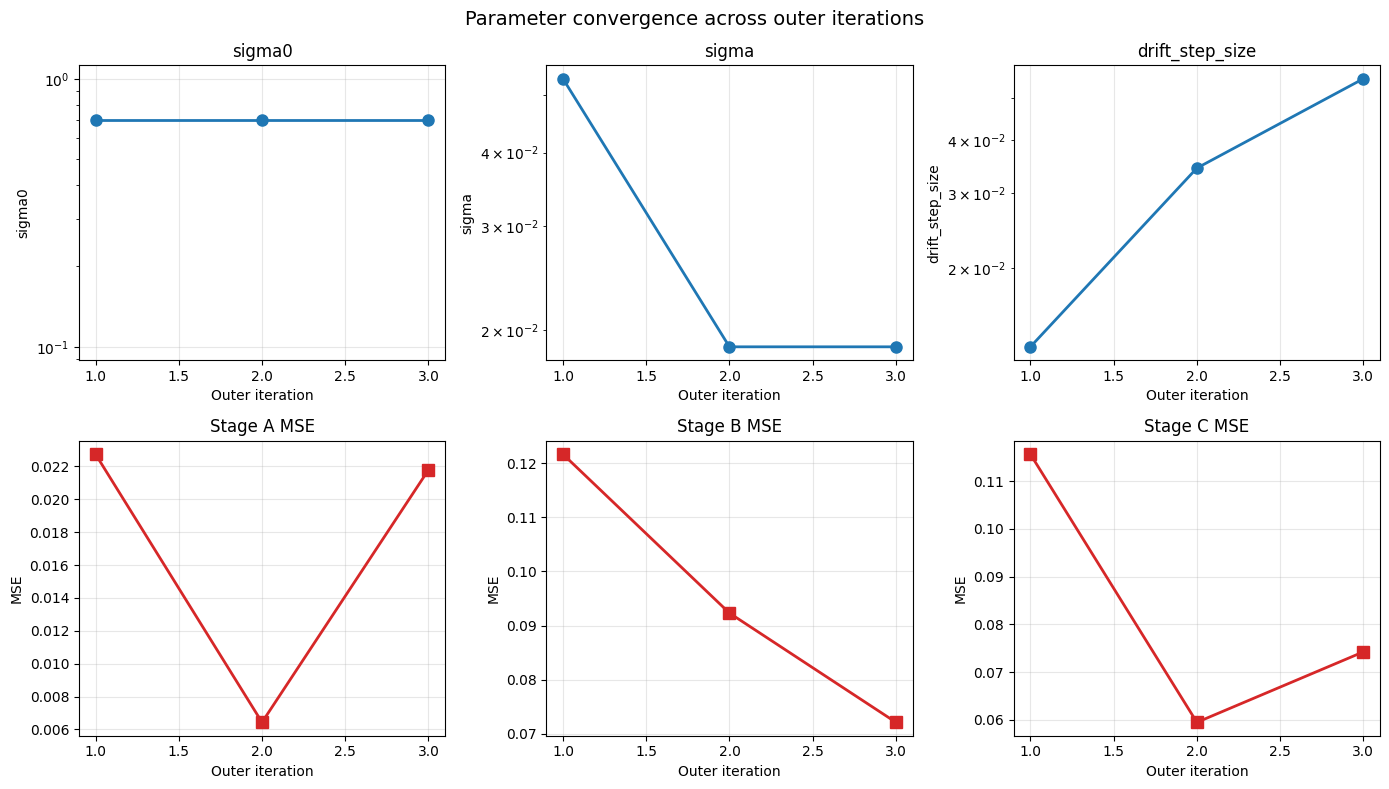

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
iters = [h["outer_iter"] + 1 for h in history]

# Top row: parameter values
for ax, key, label in zip(
    axes[0],
    ["sigma0", "sigma", "drift_step_size"],
    ["sigma0", "sigma", "drift_step_size"],
):
    vals = [h[key] for h in history]
    ax.plot(iters, vals, 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('Outer iteration')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

# Bottom row: MSE values
for ax, key, label in zip(
    axes[1],
    ["sigma0_mse", "sigma_mse", "drift_mse"],
    ["Stage A MSE", "Stage B MSE", "Stage C MSE"],
):
    vals = [h[key] for h in history]
    ax.plot(iters, vals, 's-', color='tab:red', linewidth=2, markersize=8)
    ax.set_xlabel('Outer iteration')
    ax.set_ylabel('MSE')
    ax.set_title(label)
    ax.grid(alpha=0.3)

fig.suptitle('Parameter convergence across outer iterations', fontsize=14)
fig.tight_layout()
plt.show()

## 7. Per-stage fit diagnostics (final iteration)

Sigma vs MSE and per-ISI d' for each stage in the last outer iteration.

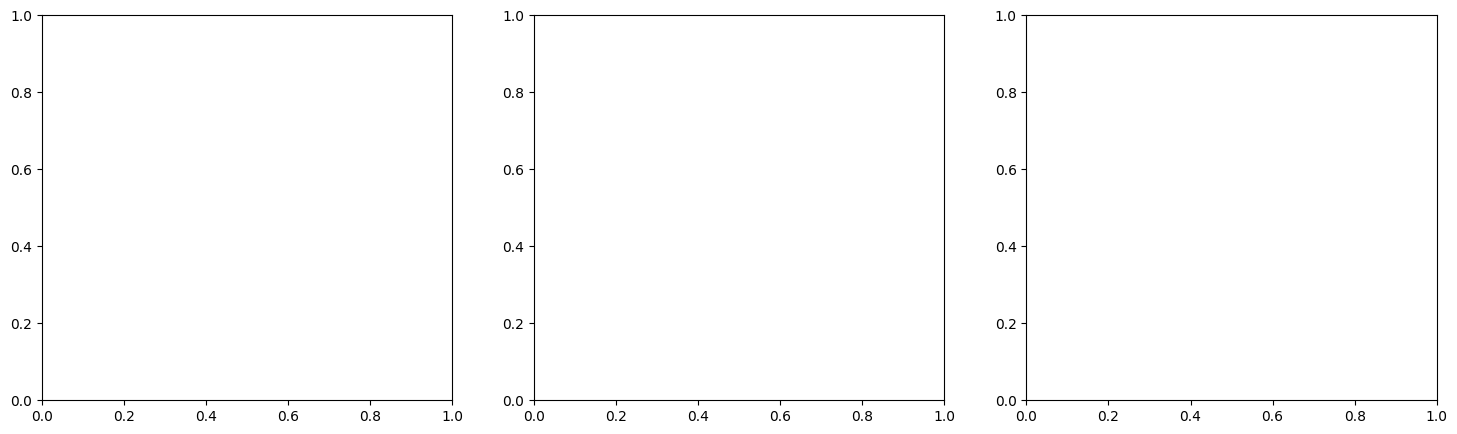

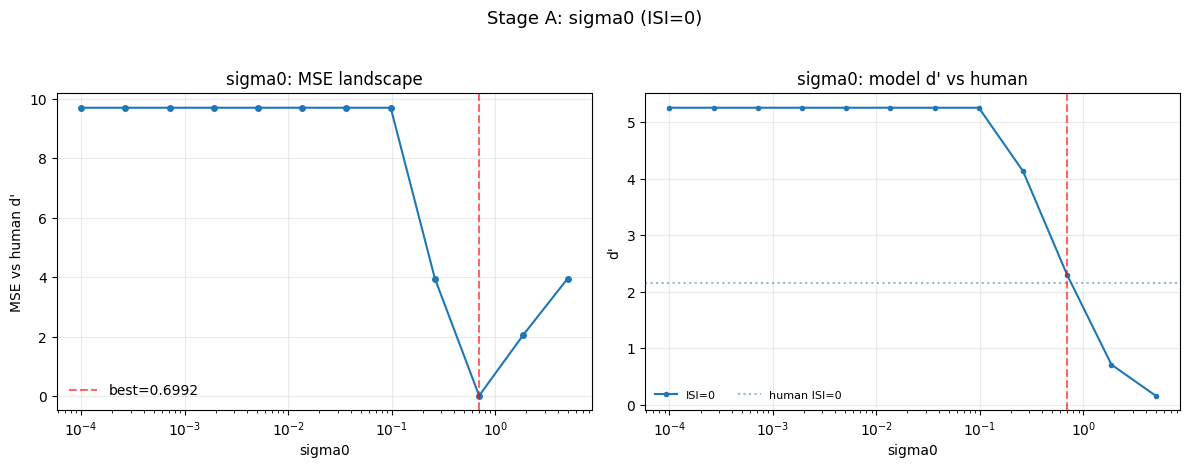

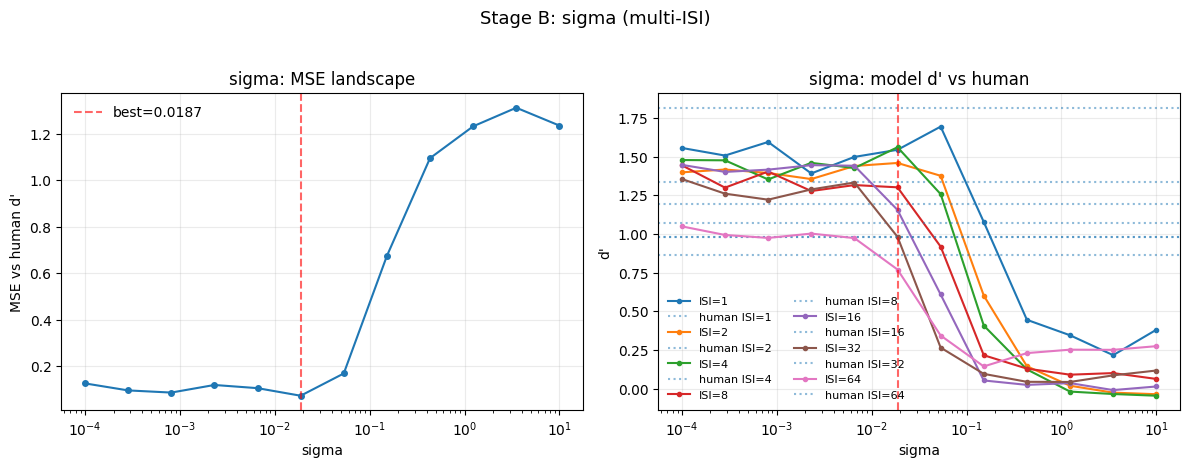

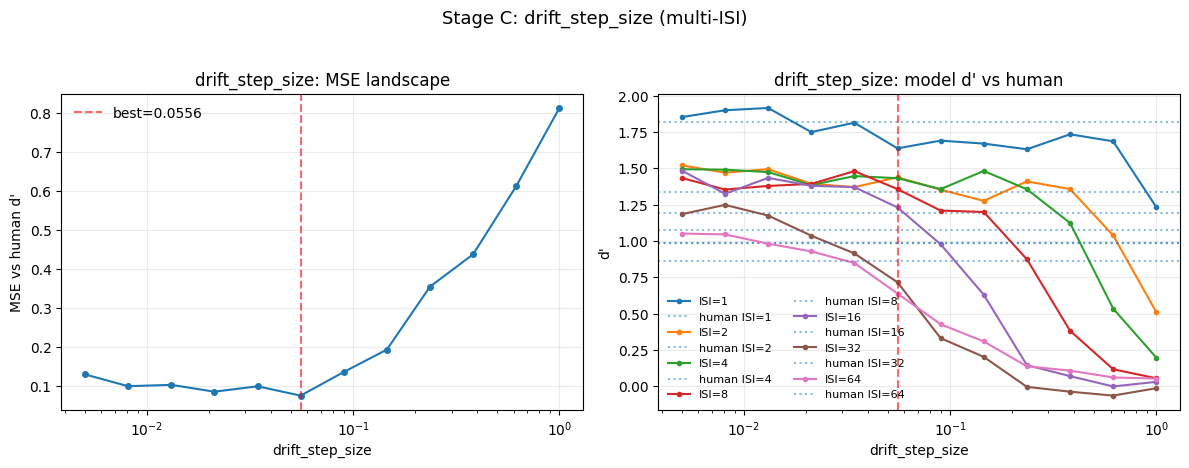

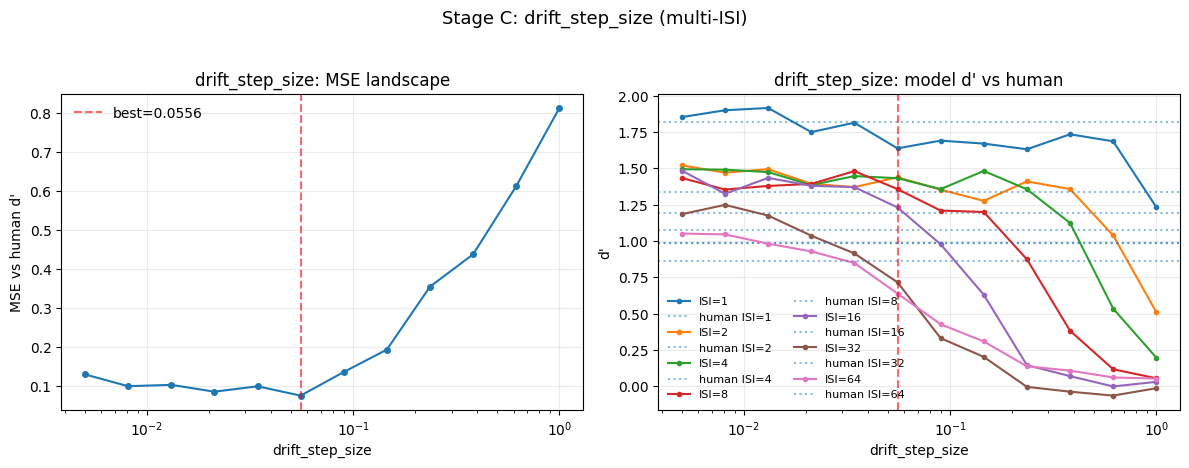

In [8]:
final = history[-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stage A
plot_sigma_fit(
    final["stage_a"],
    human_dprimes_by_isi=sigma0_human,
    title="Stage A: sigma0 (ISI=0)",
)

# Stage B
plot_sigma_fit(
    final["stage_b"],
    human_dprimes_by_isi=sigma_human,
    title="Stage B: sigma (multi-ISI)",
)

# Stage C
plot_sigma_fit(
    final["stage_c"],
    human_dprimes_by_isi=sigma_human,
    title="Stage C: drift_step_size (multi-ISI)",
)

---
## 8. Final evaluation on ALL real sequences

In [9]:
%%time

with torch.no_grad():
    final_run = run_experiment_scores_prior(
        sigma0=current_sigma0,
        sigma=current_sigma,
        noise_mode=noise_mode,
        metric=metric,
        X0=X,
        name_to_idx=name_to_idx,
        experiment_list=exp_list,
        score_model=score_fn,
        drift_step_size=current_drift,
        seed=42,
    )

model_dp = compute_model_dprime_for_run(final_run, isis)

print("Model d' curve:", model_dp)
print("Human d' curve:", human_curve)

Model d' curve: [1.44726697 1.36094381 1.33997151 1.38444912 1.29411055 1.19813789
 0.84919396 0.4571372 ]
Human d' curve: [2.14507253 1.81709503 1.33411875 1.19380765 1.0722372  0.98366202
 0.98399581 0.86493888]
CPU times: user 3min 15s, sys: 169 ms, total: 3min 15s
Wall time: 3min 16s


## 9. Summary plot: model vs human

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

isi_labels = [str(i) for i in isis]
x_pos = np.arange(len(isis))

ax.plot(x_pos, human_curve, 'ko-', label='Human', linewidth=2, markersize=8)
ax.plot(
    x_pos, model_dp, 's--', color='tab:blue', linewidth=2, markersize=8,
    label=(
        f'Model (sigma0={current_sigma0:.4f}, '
        f'sigma={current_sigma:.4f}, '
        f'drift={current_drift:.4f})'
    ),
)

ax.set_xticks(x_pos)
ax.set_xticklabels(isi_labels)
ax.set_xlabel('ISI (intervening items)')
ax.set_ylabel("d'")
ax.set_title('Sequential 3-Stage Fit: Model vs Human')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 10. Parameter summary table

In [ ]:
print("=" * 60)
print("SEQUENTIAL 3-STAGE FITTING RESULTS")
print("=" * 60)

print(f"\n{'Iter':>4}  {'sigma0':>10}  {'sigma':>10}  {'drift':>10}  "
      f"{'MSE_A':>8}  {'MSE_B':>8}  {'MSE_C':>8}")
print("-" * 72)
for h in history:
    print(f"{h['outer_iter']+1:>4}  {h['sigma0']:>10.6f}  {h['sigma']:>10.6f}  "
          f"{h['drift_step_size']:>10.6f}  {h['sigma0_mse']:>8.4f}  "
          f"{h['sigma_mse']:>8.4f}  {h['drift_mse']:>8.4f}")

print(f"\nFinal parameters:")
print(f"  sigma0          = {current_sigma0:.6f}")
print(f"  sigma           = {current_sigma:.6f}")
print(f"  drift_step_size = {current_drift:.6f}")